In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 137.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="aUgLRbSsOoYQZwK7r48V")
project = rf.workspace("gp-j4r5m").project("augmented-iklfg")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to augmented-3 in yolov8:: 100%|██████████| 27164/27164 [00:09<00:00, 2756.14it/s]


In [3]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.8 MB/s eta 0:00:00


In [4]:
# Verify installation
from ultralytics import YOLO
print("✅ Ultralytics YOLOv8 installed successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLOv8 installed successfully!


In [5]:
dataset_path = "/content/augmented-3/data.yaml"

In [6]:
model = YOLO("yolov8m.pt")  # load pre-trained YOLOv8m model

In [7]:
results = model.train(
    data=dataset_path,
    epochs=20,
    imgsz=640,           # image size
    batch=16,            # batch size
    workers=4,           # number of dataloading workers
    name="yolov8m_custom",  # experiment name
    project="/content/runs", # output directory
    patience=10,         # stop early if no improvement
    pretrained=True,     # use pretrained weights
)

Ultralytics 8.3.222 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/augmented-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=Tr

In [8]:
metrics = model.val()  # evaluate model performance
print(metrics)

Ultralytics 8.3.222 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,888,396 parameters, 0 gradients, 79.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1871.4±899.2 MB/s, size: 68.7 KB)
val: Scanning /content/augmented-3/valid/labels.cache... 1241 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1241/1241 2.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 2.3it/s 33.7s
                   all       1241       1324      0.975      0.986      0.992      0.966
             Akhenaten         32         32      0.997          1      0.995       0.96
         Amenhotep III         20         20      0.906          1       0.99      0.986
Amenhotep III and Tiye         47         47          1      0.943      0.991      0.961
Amenhotep III with Plate          6          6      0.983          1      0.995      0.895
              Augustus          8     


image 1/1 /content/augmented-3/test/images/1_0-2-_jpg.rf.a363e7cd0db402d11eefe16eeb419c8a.jpg: 640x640 1 Great Pyramids of Giza, 51.3ms
Speed: 16.7ms preprocess, 51.3ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


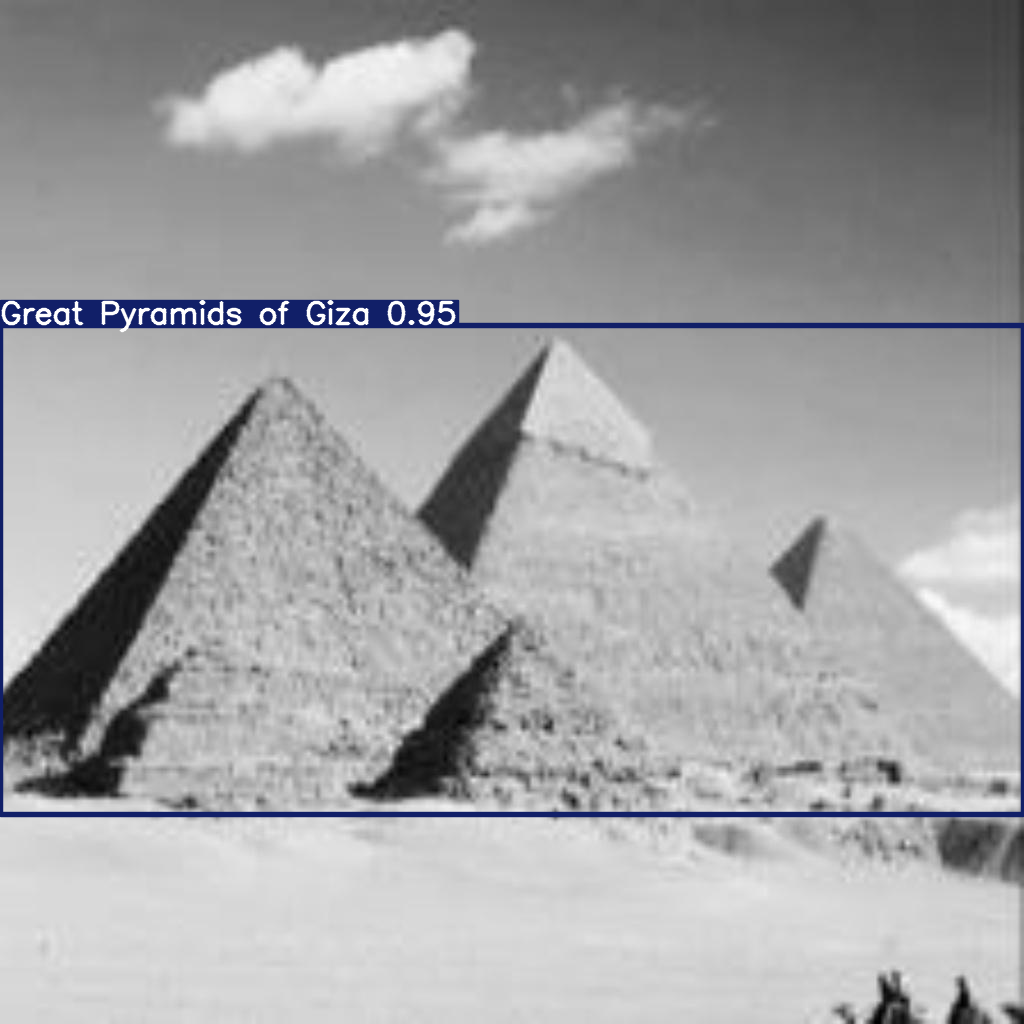

In [13]:
results = model("/content/augmented-3/test/images/1_0-2-_jpg.rf.a363e7cd0db402d11eefe16eeb419c8a.jpg", save=True)
for result in results:
  result.show()

In [14]:
metrics = model.val()  # evaluate model performance
print(metrics)

Ultralytics 8.3.222 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2742.4±993.4 MB/s, size: 104.0 KB)
val: Scanning /content/augmented-3/valid/labels.cache... 1241 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1241/1241 2.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 2.2it/s 35.5s
                   all       1241       1324      0.975      0.986      0.992      0.966
             Akhenaten         32         32      0.997          1      0.995       0.96
         Amenhotep III         20         20      0.906          1       0.99      0.986
Amenhotep III and Tiye         47         47          1      0.943      0.991      0.961
Amenhotep III with Plate          6          6      0.983          1      0.995      0.895
              Augustus          8          8      0.982          1      0.995      0.995
Bent Pyramid of King Sneferu  

In [15]:
from google.colab import files

trained_model_path = "/content/runs/yolov8m_custom/weights/best.pt"
files.download(trained_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>